# Item-Prediction-Preprocessing

#### Imports

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import datetime
import datetime
import math

global Matplotlib standard figuresize

In [3]:
plt.rcParams['figure.figsize'] = [12, 8]

set max columns

In [4]:
pd.set_option('display.max_columns', 50)

set print options

In [5]:
np.set_printoptions(threshold=10)#np.inf

set column width

In [6]:
pd.set_option('display.max_colwidth', 50)

### Preprocessing

Loading the file and some adjustments with the datatypes

In [7]:
df = pd.read_csv("csv_queue_products.csv",index_col=0)#,decimal=',')
df.index = pd.to_datetime(df.index, format='%b %d, %Y @ %H:%M:%S.%f', errors='ignore')
df = df.sort_index(axis=0 ,ascending=True)
df['size'] = [x.replace(',', '') for x in df['size']]
df['size'] = df['size'].astype(int)
df = df.fillna(0)

Focus on products queue and convert the items to a list 

In [9]:
df_prod = df[df['name']=='products'].copy()
df_prod['items'] = df_prod['items'].str.split(" ")
df_prod['items'] = [[] if type(x) != list else x for x in df_prod['items']]

In [10]:
df_prod.head()

,name,tier,size,items
timestamp,,,,
2019-12-22 07:42:02.485,products,pic,2361,"[3443940424, 702130527, 4157769312, 4080498645..."
2019-12-22 07:42:32.527,products,pic,2358,"[3443940424, 702130527, 4157769312, 4080498645..."
2019-12-22 07:43:02.872,products,pic,2355,"[3443940424, 702130527, 4157769312, 4080498645..."
2019-12-22 07:43:32.718,products,pic,2351,"[3443940424, 702130527, 4157769312, 4080498645..."
2019-12-22 07:44:03.363,products,pic,2348,"[3443940424, 702130527, 4157769312, 4080498645..."


In [11]:
df_prod.dtypes

name     object
tier     object
size      int64
items    object
dtype: object

## Add Features

    diff - difference of size compared to prior timestamp

In [12]:
df_prod['diff'] = df_prod['size'] - df_prod['size'].shift(1)
df_prod = df_prod.fillna(0)

Overview of the range of items entering/leaving the queue

In [14]:
set(df_prod['diff'])

{-12.0,
 -9.0,
 -7.0,
 -6.0,
 -5.0,
 -4.0,
 -3.0,
 -2.0,
 -1.0,
 0.0,
 1.0,
 2.0,
 3.0,
 4.0,
 6.0,
 10.0,
 17.0}

from 12 leaving the queue to 17 entering the q

In [17]:
sum(df_prod['diff']) / len(df_prod)

-2.6952054794520546

Mean difference is 2.7

Creating extra columns for items leaving/entering the queue and their respective size

In [15]:
lists = df_prod['items'].tolist()
current = lists[0]
diff_sets = [[]]
diff_sets_rev = [[]]
for next_list in lists[1:]:
    diff_sets.append(sorted(set(current).difference(set(next_list))))
    diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
    current = next_list

    diff_items - items that left the queue during last period (30s)
    diff_items_rev - items that entered the queue 

In [16]:
df_prod['diff_items'] = diff_sets
df_prod['diff_items_rev'] = diff_sets_rev

    n_removed_items - number of items removed from the queue
    n_added_items - number of items added to the queue

In [17]:
df_prod['n_removed_items'] = df_prod['diff_items'].apply(lambda x: len(x))
df_prod['n_added_items'] = df_prod['diff_items_rev'].apply(lambda x: len(x))

Final overall Dataframe

In [18]:
df_prod[df_prod['size']<30]

,name,tier,size,items,diff,diff_items,diff_items_rev,n_removed_items,n_added_items
timestamp,,,,,,,,,
2019-12-22 14:36:02.057,products,pic,29,"[713452185, 713455101, 3953049219, 3077385486,...",-5.0,"[1399439745, 2851856368, 3115155905, 408199603...",[],5,0
2019-12-22 14:36:32.450,products,pic,25,"[713452185, 713455101, 3953049219, 3077385486,...",-4.0,"[1858163218, 2576644546, 2576644667, 2714752680]",[],4,0
2019-12-22 14:37:03.582,products,pic,25,"[3953049219, 3077385486, 2101224659, 131962295...",0.0,"[3373424667, 4085211766, 713452185, 713455101]","[1210914523, 1211838044, 1240467195, 2021184670]",4,4
2019-12-22 14:37:33.248,products,pic,19,"[3077385486, 2101224659, 1319622950, 177542858...",-6.0,"[1210914523, 1211838044, 1240467195, 202118467...",[],6,0
2019-12-22 14:38:03.081,products,pic,17,"[2101224659, 1319622950, 1775428588, 131023878...",-2.0,"[153890170, 3077385486]",[],2,0
2019-12-22 14:38:33.475,products,pic,20,"[2101224659, 1319622950, 1775428588, 131023878...",3.0,"[2475996948, 2787251396, 2787253378]","[3515380892, 3671816145, 3672739666, 374193648...",3,6
2019-12-22 14:39:01.998,products,pic,21,"[1319622950, 460589361, 460590322, 460591283, ...",1.0,"[1775428588, 2101224659, 4078555044, 713450511]","[1394322624, 1394323585, 460589361, 460590322,...",4,5
2019-12-22 14:39:32.893,products,pic,9,"[1319622950, 1310238785, 3029071872, 74533036,...",-12.0,"[1394322624, 1394323585, 3027939842, 351538089...",[],12,0
2019-12-22 14:40:04.018,products,pic,8,"[1319622950, 1310238785, 3029071872, 74533036,...",-1.0,"[2476954113, 2684276487]",[44405545],2,1


## Exploration Plots

In [19]:
pro_s = df_prod['size']

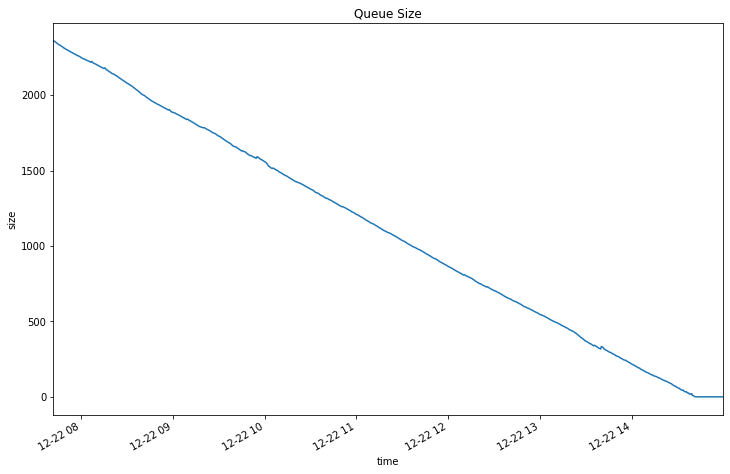

In [20]:
pro_s.plot()
plt.title("Queue Size")
plt.xlabel("time")
plt.ylabel("size")
plt.yscale("linear")

nearly constant linear decrease of queue size

In [21]:
pro_d = df_prod['diff']

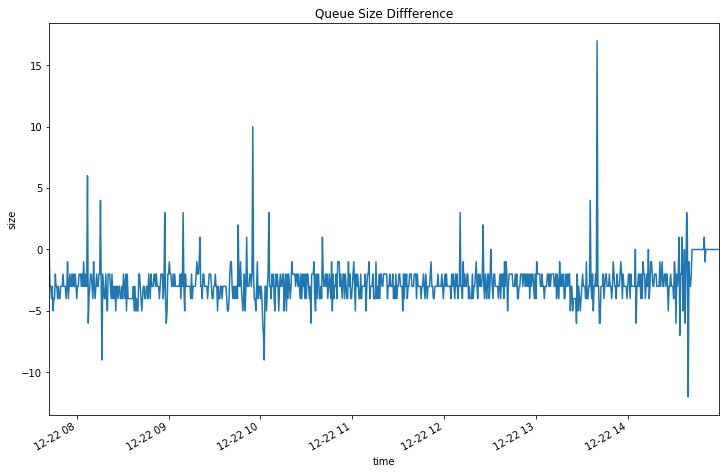

In [22]:
pro_d.plot()
plt.title("Queue Size Diffference")
plt.xlabel("time")
plt.ylabel("size")
plt.yscale("linear")

# Transforming the Data for NN

### MultiLabelBinarizer

To get for each item an overview of when they entered and left the queue, we have to first use the MultiLabelBinarizer and transform the dataframe

In [24]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
df_mlb = pd.DataFrame(mlb.fit_transform(df_prod['items']),columns=mlb.classes_)

In [25]:
df_mlb

,1001383363,1001682754,1001682878,1001682945,1002036037,1002125410,10030171,1005376838,1005376931,1005376962,1005377029,1005397019,1005397143,1010281570,10119543,1013843513,1017139769,1019378353,1019382197,1019705995,1023410583,1024163208,1024334941,102777439,102872337,...,9246249,926965825,927596575,927655568,927656157,927902454,928341350,928579089,928579678,937670698,938277677,939406481,943839896,943839904,955838550,958160552,958865451,959262755,962347434,96744619,970741170,975842028,987399183,987400299,987762752
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
873,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
874,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Average time of items in the Queue

In [26]:
mea = 0 
for item in df_mlb.columns:
    mea += sum(df_mlb[item])

In [27]:
mea/len(df_mlb.columns) * 30 / 60 / 60 #30second / minutes / hour

3.205957108816521

    average time in queue 3,2h

Now we transform the binarized dataframe into an ascending order of steps the items have been in the queue

In [28]:
cum = df_mlb.cumsum()

In [29]:
cum

,1001383363,1001682754,1001682878,1001682945,1002036037,1002125410,10030171,1005376838,1005376931,1005376962,1005377029,1005397019,1005397143,1010281570,10119543,1013843513,1017139769,1019378353,1019382197,1019705995,1023410583,1024163208,1024334941,102777439,102872337,...,9246249,926965825,927596575,927655568,927656157,927902454,928341350,928579089,928579678,937670698,938277677,939406481,943839896,943839904,955838550,958160552,958865451,959262755,962347434,96744619,970741170,975842028,987399183,987400299,987762752
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,0,2,2,2,2,2
2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3
3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,4,4,4
4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,0,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,11,562,726,586,485,676,322,735,648,747,768,649,575,415,680,44,86,738,564,459,711,159,699,689,282,...,575,55,295,734,375,757,814,767,647,623,143,249,552,536,221,370,471,123,90,2,132,285,425,663,504
872,11,562,726,586,485,676,322,735,648,747,768,649,575,415,680,44,86,738,564,459,711,159,699,689,282,...,575,55,295,734,375,757,814,767,647,623,143,249,552,536,221,370,471,123,90,2,132,285,425,663,504
873,11,562,726,586,485,676,322,735,648,747,768,649,575,415,680,44,86,738,564,459,711,159,699,689,282,...,575,55,295,734,375,757,814,767,647,623,143,249,552,536,221,370,471,123,90,2,132,285,425,663,504
874,11,562,726,586,485,676,322,735,648,747,768,649,575,415,680,44,86,738,564,459,711,159,699,689,282,...,575,55,295,734,375,757,814,767,647,623,143,249,552,536,221,370,471,123,90,2,132,285,425,663,504


For the feature target y, we take need the remaining time of the items in the queue, so we have to reverse the variables

In [30]:
cum_rev = df_mlb.iloc[::-1].cumsum().iloc[::-1]

In [31]:
cum_rev

,1001383363,1001682754,1001682878,1001682945,1002036037,1002125410,10030171,1005376838,1005376931,1005376962,1005377029,1005397019,1005397143,1010281570,10119543,1013843513,1017139769,1019378353,1019382197,1019705995,1023410583,1024163208,1024334941,102777439,102872337,...,9246249,926965825,927596575,927655568,927656157,927902454,928341350,928579089,928579678,937670698,938277677,939406481,943839896,943839904,955838550,958160552,958865451,959262755,962347434,96744619,970741170,975842028,987399183,987400299,987762752
0,11,562,726,586,485,676,322,735,648,747,768,649,575,415,680,44,86,738,564,459,711,159,699,689,282,...,575,55,295,734,375,757,814,767,647,623,143,249,552,536,221,370,471,123,90,2,132,285,425,663,504
1,10,561,725,585,484,675,321,734,647,746,767,648,574,414,679,43,85,737,563,458,710,158,698,688,281,...,574,54,294,733,374,756,813,766,646,622,142,248,551,535,220,369,470,122,89,2,131,284,424,662,503
2,9,560,724,584,483,674,320,733,646,745,766,647,573,413,678,42,84,736,562,457,709,157,697,687,280,...,573,53,293,732,373,755,812,765,645,621,141,247,550,534,219,368,469,121,88,2,130,283,423,661,502
3,8,559,723,583,482,673,319,732,645,744,765,646,572,412,677,41,83,735,561,456,708,156,696,686,279,...,572,52,292,731,372,754,811,764,644,620,140,246,549,533,218,367,468,120,87,2,129,282,422,660,501
4,7,558,722,582,481,672,318,731,644,743,764,645,571,411,676,40,82,734,560,455,707,155,695,685,278,...,571,51,291,730,371,753,810,763,643,619,139,245,548,532,217,366,467,119,86,2,128,281,421,659,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
873,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
874,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


To get rid of timesteps where an item isn´t in the queue a mask is filtering them out

In [32]:
maske = df_mlb['1001383363'] !=0

In [33]:
maske

0       True
1       True
2       True
3       True
4       True
       ...  
871    False
872    False
873    False
874    False
875    False
Name: 1001383363, Length: 876, dtype: bool

In [34]:
cum_rev['1001383363'][maske]

0     11
1     10
2      9
3      8
4      7
5      6
6      5
7      4
8      3
9      2
10     1
Name: 1001383363, dtype: int64

In [35]:
tem = pd.DataFrame(cum['1001383363'][maske])

In [36]:
tem.rename(columns = {'1001383363': 'n_steps'})

,n_steps
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [37]:
Q_items = df_prod['items'].values

In [38]:
def create_dataset(df_binarized, df_overall):
    """ Creates two lists containing the dataset 
    for the features X and the variable target y, 
    based on two dataframes
    
    Parameters:
    df_binarized : a multilabel binarized dataframe
    df_overall : a non binarized dataframe
    
    Returns : 
    X : a list of dataframes enriched with features
    y : a list of target variables - the remaining steps in Q
    """
    
    
    # extract general features   
    # for each item create a corresponding dataset X, y and then concatenate
    
    # cumsum for ascending steps in Q
    Xs = df_binarized.cumsum()
    # reverse, cumsum, reverse again for remaining steps in Q
    Ys = df_binarized.iloc[::-1].cumsum().iloc[::-1]
    
    # get features from df_overall
    Q_sizes = df_overall['size'].values
    Q_items = df_overall['items'].values
    n_added = df_overall['n_added_items'].values
    n_removed = df_overall['n_removed_items'].values
    
    X = list()
    y = list()
    
    for item in df_binarized.columns:
        # for one item select the rows where it is still in Q
        mask = df_binarized[item] != 0
        
        # labels to predict (how many remaining steps in Q)
        Y_item = Ys[item][mask]
        
        # create features (number of steps in Q already in Xs)
        X_item = pd.DataFrame(Xs[item][mask])
        X_item = X_item.rename(columns = {item: 'n_steps_in_Q'})
        
        # get the Queue sizes
        X_item['Q_size'] = Q_sizes[mask]
        
        # Q difference 
        X_item['n_added'] = n_added[mask]
        X_item['n_removed'] = n_removed[mask]
        X.append(X_item)
        y.append(Y_item)
    return X, y

In [39]:
X, y = create_dataset(df_mlb, df_prod)

One sample of the X dataset and corresponding y dataset

In [40]:
X[0]

,n_steps_in_Q,Q_size,n_added,n_removed
0,1,2361,0,0
1,2,2358,0,3
2,3,2355,0,3
3,4,2351,0,4
4,5,2348,0,3
5,6,2343,0,5
6,7,2339,0,4
7,8,2335,0,4
8,9,2333,0,2
9,10,2330,0,3


In [41]:
y[0]

0     11
1     10
2      9
3      8
4      7
5      6
6      5
7      4
8      3
9      2
10     1
Name: 1001383363, dtype: int64

## Pickle Transformed DS

In [42]:
import pickle

In [43]:
pickle.dump(X, open("X_ds_8h.p","wb"))

In [44]:
pickle.dump(y, open("y_ds_8h.p","wb"))